# 1.7 Resource permissions

**Responsible:** _(Aldo Patrone)_

Builds the permission model used by "resources/permissions.py" and exports it as an artifact the engine loads at runtime.

- **Basic:** resource-activity matrix. A resource may perform an activity iff it performed it before in the log.
- **Advanced:** role discovery with **OrdinoR** (reference [3], Yang et al. 2022). The full OrdinoR pipeline (execution contexts -> resource feature profiles -> group discovery -> group profiling) is run offline in a separate venv via "scripts/ordinor_role_discovery.py", which exports "results/permissions_roles.json". A resource may perform an activity iff its discovered role's capabilities cover it. An OrdinoR-style fallback ("resources/role_discovery.py", agglomerative clustering on resource profiles) is run inline below for in-environment comparison.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resources.log_loader import load_slim_log
from resources.permissions import PermissionModel
from resources import role_discovery

df = load_slim_log('../data/BPI Challenge 2017.xes', '../data/bpic17_slim.parquet')
activities = sorted(df['concept:name'].dropna().astype(str).unique())
print(len(df), 'events,', df['org:resource'].nunique(), 'resources,', len(activities), 'activities')

1202267 events, 149 resources, 26 activities


## Basic: resource-activity matrix

In [2]:
basic = PermissionModel(df, artifact_path=None)
basic_counts = {a: len(basic.who_can(a)) for a in activities}
print('permits per activity (basic): min %d, median %d, max %d' % (
    min(basic_counts.values()), int(np.median(list(basic_counts.values()))), max(basic_counts.values())))

permits per activity (basic): min 1, median 109, max 144


## Advanced: OrdinoR role discovery
The OrdinoR artifact is produced offline (see module docstring of "scripts/ordinor_role_discovery.py"). Load it here. If it is missing fall back to the in-environment OrdinoR-style clustering so the notebook is self-contained.

In [3]:
ART = '../results/permissions_roles.json'
if os.path.exists(ART):
    adv_map = {a: set(rs) for a, rs in json.load(open(ART)).items()}
    source = 'OrdinoR (offline)'
else:
    adv_map, meta = role_discovery.discover_roles(df, n_groups=14)
    adv_map = {a: set(rs) for a, rs in adv_map.items()}
    source = 'OrdinoR-style fallback (inline)'
print('advanced permission source:', source, '|', len(adv_map), 'activities covered')

# also run the inline fallback for comparison regardless
fb_map, fb_meta = role_discovery.discover_roles(df, n_groups=14)
print('fallback groups:', fb_meta['n_groups'], '| group sizes:', [g['n_members'] for g in fb_meta['groups']])

advanced permission source: OrdinoR (offline) | 26 activities covered
fallback groups: 14 | group sizes: [8, 27, 42, 21, 3, 5, 10, 1, 6, 2, 10, 1, 10, 3]


## Basic vs. advanced: permission breadth
Role discovery generalizes permissions: a resource inherits its role's capabilities even for activities it has not personally executed yet. Never droping below the observed matrix (floor), so coverage is monotone.

extra (activity, resource) permissions added by roles: 872
saved ../results/permissions_basic_vs_advanced.png


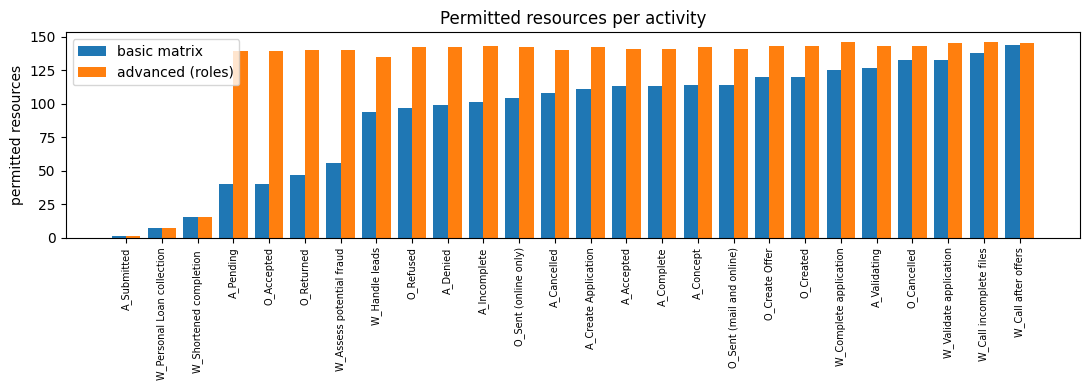

In [4]:
added = sum(len(adv_map.get(a, set()) - basic.who_can(a)) for a in activities)
print('extra (activity, resource) permissions added by roles:', added)

adv_counts = {a: len(adv_map.get(a, set())) for a in activities}
order = sorted(activities, key=lambda a: basic_counts[a])
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, [basic_counts[a] for a in order], width=0.4, label='basic matrix')
ax.bar(x + 0.2, [adv_counts[a] for a in order], width=0.4, label='advanced (roles)')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel('permitted resources'); ax.legend(); ax.set_title('Permitted resources per activity')
fig.tight_layout(); fig.savefig('../results/permissions_basic_vs_advanced.png', dpi=120)
print('saved ../results/permissions_basic_vs_advanced.png')

**Result:** OrdinoR groups the 149 resources into 14 roles and assigns each role the execution contexts (activities) its members perform. Mapping roles back to activities adds several hundred role-based permissions over the plain resource-activity matrix, modeling that resources in the same role are interchangeable, while the observed-performer floor guarantees no activity loses coverage.